In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

In [4]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,0.0,High,Mid Floor


In [5]:
df['furnishing_type'].value_counts()

furnishing_type
0.0    2349
1.0    1018
2.0     187
Name: count, dtype: int64

In [6]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [7]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,unfurnished,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,unfurnished,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,unfurnished,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,semifurnished,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,unfurnished,High,Mid Floor


In [8]:
X = df.drop(columns=['price'])
y = df['price']

In [9]:
# Applying the log1p transformation to the target variable
y_transformed = np.log1p(y)

### Ordinal Encoding

In [10]:
columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

In [10]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode)
    ], 
    remainder='passthrough'
)

In [11]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [12]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [18]:
scores.mean(),scores.std()

(np.float64(0.7363096633436828), np.float64(0.03238005754429941))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [15]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
y_pred = np.expm1(y_pred)

In [23]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.9463822160089357

In [20]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [21]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [22]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [23]:
model_output

[['linear_reg', np.float64(0.7363096633436828), 0.9463822160089357],
 ['svr', np.float64(0.7642012011196353), 0.847263647348393],
 ['ridge', np.float64(0.7363125343993552), 0.9463387741853369],
 ['LASSO', np.float64(0.05943378064493572), 1.528905986892753],
 ['decision tree', np.float64(0.7658648050493427), 0.7387887514884974],
 ['random forest', np.float64(0.8813479000091646), 0.53151148343142],
 ['extra trees', np.float64(0.8680613574741031), 0.5486530036904793],
 ['gradient boosting', np.float64(0.8725503427240111), 0.5760506721008158],
 ['adaboost', np.float64(0.7532842036425655), 0.8351061484242843],
 ['mlp', np.float64(0.8137144515510603), 0.6665034286896747],
 ['xgboost', np.float64(0.8894876835260124), 0.5040475141482346]]

In [24]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [25]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.889488,0.504048
5,random forest,0.881348,0.531511
6,extra trees,0.868061,0.548653
7,gradient boosting,0.872550,0.576051
9,mlp,0.813714,0.666503
4,decision tree,0.765865,0.738789
8,adaboost,0.753284,0.835106
1,svr,0.764201,0.847264
2,ridge,0.736313,0.946339
0,linear_reg,0.736310,0.946382


In [8]:
import xgboost as xgb
import optuna
import numpy as np

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================================================
# SPLIT DATA
# =========================================================

# First split: Train+Valid and Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_transformed,
    test_size=0.2,
    random_state=42
)

# Second split: Train and Validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

# =========================================================
# HANDLE CATEGORICAL COLUMNS
# =========================================================

cat_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

for df in [X_train, X_valid, X_test]:

    for col in cat_cols:
        df[col] = df[col].astype('category')

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================

def objective(trial):

    params = {

        # Core Parameters
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'enable_categorical': True,

        # Boosting Parameters
        'n_estimators': 2000,

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            4,
            8
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            10
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            0.9
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            0.9
        ),

        # Regularization
        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            1e-8,
            1.0,
            log=True
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            1e-8,
            1.0,
            log=True
        ),

        # Misc
        'early_stopping_rounds': 50,
        'random_state': 42,
        'n_jobs': -1
    }

    # =====================================================
    # MODEL
    # =====================================================

    model = xgb.XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=False
    )

    # =====================================================
    # VALIDATION PREDICTIONS
    # =====================================================

    preds = model.predict(X_valid)

    # =====================================================
    # MAE
    # =====================================================

    mae = mean_absolute_error(
        np.expm1(y_valid),
        np.expm1(preds)
    )

    return mae

# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(
    direction='minimize',
    study_name='XGBoost_RealEstate_Optimization'
)

# =========================================================
# RUN OPTIMIZATION
# =========================================================

study.optimize(
    objective,
    n_trials=50
)

# =========================================================
# BEST RESULTS
# =========================================================

print("\n====================================")
print(f"Best Validation MAE: {study.best_value:.4f}")

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

print("====================================")

# =========================================================
# FINAL MODEL TRAINING
# =========================================================

best_params = study.best_params

best_params.update({

    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'enable_categorical': True,

    'n_estimators': 3000,
    'early_stopping_rounds': 50,

    'random_state': 42,
    'n_jobs': -1
})

for col in cat_cols:
    X_train_full[col] = X_train_full[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')

final_xgb_model = xgb.XGBRegressor(**best_params)

# Train on train_full
final_xgb_model.fit(

    X_train_full,
    y_train_full,

    eval_set=[(X_valid, y_valid)],

    verbose=100
)

# =========================================================
# FINAL TEST EVALUATION
# =========================================================

final_preds = final_xgb_model.predict(X_test)

final_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(final_preds)
)

print("\n====================================")
print(f"Final Test MAE: {final_mae:.4f}")
print(f"Best Iteration: {final_xgb_model.best_iteration}")
print("====================================")

[I 2026-05-19 16:37:18,465] A new study created in memory with name: XGBoost_RealEstate_Optimization
[I 2026-05-19 16:37:19,079] Trial 0 finished with value: 0.5402631363047447 and parameters: {'learning_rate': 0.09708995236111063, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.8191570628685615, 'colsample_bytree': 0.8968072952264664, 'reg_alpha': 9.0377054801445e-06, 'reg_lambda': 0.0004755559947447404}. Best is trial 0 with value: 0.5402631363047447.
[I 2026-05-19 16:37:23,263] Trial 1 finished with value: 0.5247458484187487 and parameters: {'learning_rate': 0.02136408017016367, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.8661226153400785, 'colsample_bytree': 0.8982438473279833, 'reg_alpha': 0.007459331619904668, 'reg_lambda': 1.944973216540247e-08}. Best is trial 1 with value: 0.5247458484187487.
[I 2026-05-19 16:37:26,732] Trial 2 finished with value: 0.5450366534688141 and parameters: {'learning_rate': 0.04498360641563317, 'max_depth': 4, 'min_child_weight': 6, '


Best Validation MAE: 0.4970

Best Parameters:
learning_rate: 0.01851460091595995
max_depth: 8
min_child_weight: 2
subsample: 0.8406808808698739
colsample_bytree: 0.8608264410143817
reg_alpha: 2.4645539589167104e-06
reg_lambda: 0.02448568352613505
[0]	validation_0-rmse:0.56731
[100]	validation_0-rmse:0.13360
[200]	validation_0-rmse:0.06740
[300]	validation_0-rmse:0.04934
[400]	validation_0-rmse:0.03861
[500]	validation_0-rmse:0.03125
[600]	validation_0-rmse:0.02519
[700]	validation_0-rmse:0.02090
[800]	validation_0-rmse:0.01777
[900]	validation_0-rmse:0.01537
[1000]	validation_0-rmse:0.01336
[1100]	validation_0-rmse:0.01180
[1200]	validation_0-rmse:0.01048
[1300]	validation_0-rmse:0.00947
[1400]	validation_0-rmse:0.00859
[1500]	validation_0-rmse:0.00787
[1600]	validation_0-rmse:0.00731
[1700]	validation_0-rmse:0.00684
[1800]	validation_0-rmse:0.00636
[1900]	validation_0-rmse:0.00605
[2000]	validation_0-rmse:0.00582
[2100]	validation_0-rmse:0.00562
[2200]	validation_0-rmse:0.00537
[2300

In [ ]:

import xgboost as xgb
import optuna
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# CATEGORICAL COLUMNS CONVERSION 
# =========================================================

cat_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

def convert_categories(df):
    df = df.copy()
    for col in cat_cols:
        # Ensures uniform category mapping across all future splits
        df[col] = df[col].astype('category')
    return df

# Assuming X and y_transformed are already defined in your notebook
X = convert_categories(X)

# =========================================================
# TRAIN / VALID / TEST SPLIT
# =========================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_transformed,
    test_size=0.2,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42
)

# =========================================================
# OPTUNA OBJECTIVE
# =========================================================

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical': True,
        
        # TUNING PARAMETERS
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        
        # TRAINING
        'n_estimators': 3000,
        'early_stopping_rounds': 100,
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    preds = model.predict(X_valid)

    # ORIGINAL SCALE MAE
    y_valid_actual = np.expm1(y_valid)
    preds_actual = np.expm1(preds)

    mae = mean_absolute_error(y_valid_actual, preds_actual)
    return mae

# =========================================================
# RUN OPTIMIZATION
# =========================================================

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n====================================")
print(f"Best Validation MAE: {study.best_value:.4f}")
print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("====================================")

# =========================================================
# GET BEST ITERATION
# =========================================================

best_trial_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror',
    eval_metric='mae',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=3000,
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

best_trial_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

best_iteration = best_trial_model.best_iteration
print(f"\nBest Iteration: {best_iteration}")

# =========================================================
# FINAL TRAINING DATA
# =========================================================

# Combining Train + Valid for the final model
X_final_train = pd.concat([X_train, X_valid])
y_final_train = pd.concat([y_train, y_valid])

# =========================================================
# FINAL MODEL
# =========================================================

final_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror',
    eval_metric='mae',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=best_iteration, # Use the exact iteration count found above
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_final_train,
    y_final_train,
    verbose=False
)

# =========================================================
# TEST PREDICTIONS & METRICS
# =========================================================

preds = final_model.predict(X_test)

y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

final_mae = mean_absolute_error(y_test_actual, preds_actual)
final_r2 = r2_score(y_test_actual, preds_actual)

print("\n====================================")
print(f"Final Test MAE: {final_mae:.4f} Cr")
print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")
print(f"Final Test R² Score: {final_r2:.4f}")
print("====================================")

# =========================================================
# SAVE MODEL
# =========================================================

with open('final_xgb_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

print("\nModel saved successfully!")

[I 2026-05-19 19:10:31,815] A new study created in memory with name: no-name-fa43e898-85d2-4d21-8b17-2430e24f5367
[I 2026-05-19 19:10:33,245] Trial 0 finished with value: 0.5516224798837739 and parameters: {'learning_rate': 0.06213939685457984, 'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.8491981475928824, 'colsample_bytree': 0.7974983612156943, 'reg_alpha': 0.0019029039721307588, 'reg_lambda': 6.78500812902769e-08}. Best is trial 0 with value: 0.5516224798837739.
[I 2026-05-19 19:10:34,202] Trial 1 finished with value: 0.5568028267510956 and parameters: {'learning_rate': 0.09260733067589243, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.7577811729475687, 'colsample_bytree': 0.7109305362026175, 'reg_alpha': 9.425596067667214e-05, 'reg_lambda': 1.1726288340744481e-07}. Best is trial 0 with value: 0.5516224798837739.
[I 2026-05-19 19:10:36,608] Trial 2 finished with value: 0.5039439237411076 and parameters: {'learning_rate': 0.01889917086447993, 'max_depth': 7, 'min_chil


Best Validation MAE: 0.5024

Best Parameters:
  learning_rate: 0.019282492959763163
  max_depth: 7
  min_child_weight: 2
  subsample: 0.7943076985261203
  colsample_bytree: 0.8057904237322374
  reg_alpha: 1.5026553475613257e-06
  reg_lambda: 0.010710333621126108

Best Iteration: 841

Final Test MAE: 0.4231 Cr
Equivalent Error: ₹42.31 Lakhs
Final Test R² Score: 0.8745

Model saved successfully!


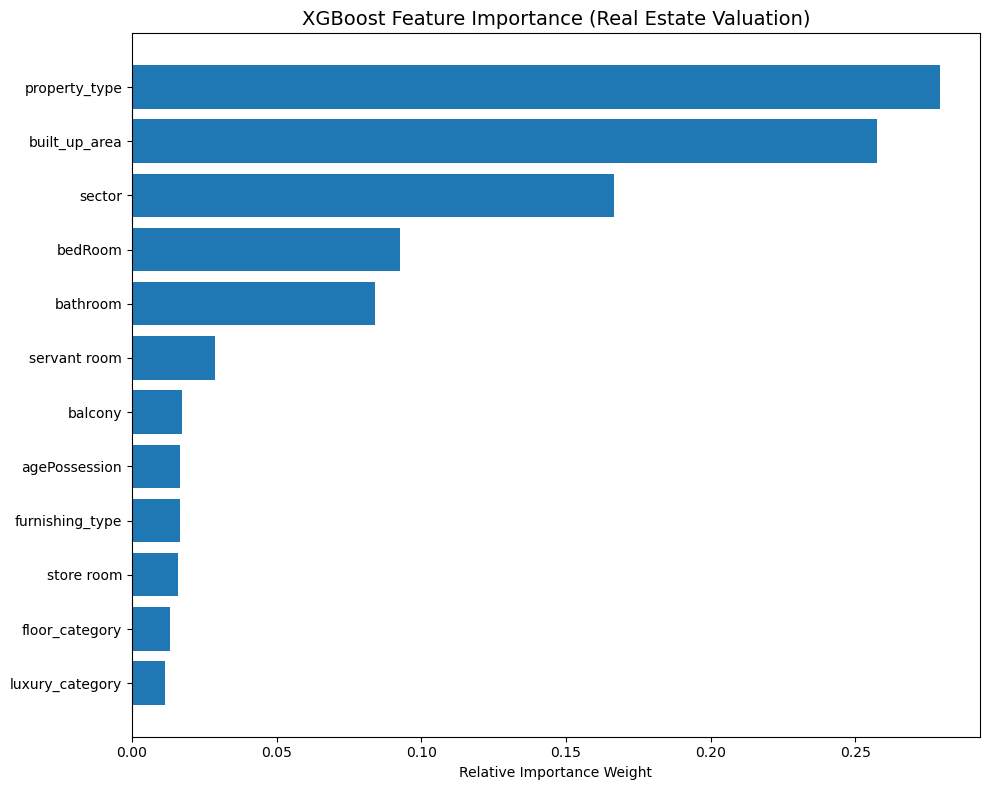

In [23]:
import matplotlib.pyplot as plt

# Get feature importances from your final model
importances = final_model.feature_importances_
feature_names = X_train.columns

# Sort them
sorted_idx = importances.argsort()

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='#1f77b4')
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.title('XGBoost Feature Importance (Real Estate Valuation)', fontsize=14)
plt.xlabel('Relative Importance Weight')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import r2_score
import numpy as np

# 1. Generate predictions using your final trained model
preds = final_model.predict(X_test)

# 2. Calculate R2 Score (reverting the log transformation with expm1)
r2 = r2_score(np.expm1(y_test), np.expm1(preds))

print(f"R² Score: {r2:.4f}")

R² Score: 0.8642


### OneHotEncoding

In [9]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first'),['sector','agePossession','furnishing_type'])
    ], 
    remainder='passthrough'
)

In [11]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [12]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [29]:
scores.mean()

np.float64(0.8546096323539831)

In [30]:
scores.std()

np.float64(0.015996824102062494)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [32]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred = pipeline.predict(X_test)

In [34]:
y_pred = np.expm1(y_pred)

In [35]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.6497673463840029

In [13]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [37]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [38]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [39]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [40]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.893710,0.464123
10,xgboost,0.895850,0.493456
5,random forest,0.891150,0.509630
9,mlp,0.874948,0.553618
7,gradient boosting,0.876612,0.567897
0,linear_reg,0.854610,0.649767
2,ridge,0.854685,0.652853
4,decision tree,0.808241,0.695814
8,adaboost,0.755705,0.818513
1,svr,0.769741,0.834124


In [9]:
import optuna
import numpy as np

from sklearn.ensemble import ExtraTreesRegressor

from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    cross_val_score,
    KFold,
    train_test_split
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

from sklearn.compose import (
    ColumnTransformer,
    make_column_selector
)

from sklearn.preprocessing import OneHotEncoder

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_transformed,
    test_size=0.2,
    random_state=42
)

# =========================================================
# PREPROCESSOR
# =========================================================
# No scaling needed for tree models

robust_preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            'passthrough',
            make_column_selector(
                dtype_include=np.number
            )
        ),

        (
            'cat',

            OneHotEncoder(
                handle_unknown='ignore'
            ),

            make_column_selector(
                dtype_include=['object', 'category']
            )
        )
    ]
)

# =========================================================
# OPTUNA OBJECTIVE
# =========================================================

def objective_final(trial):

    params = {

        # -------------------------------------------------
        # MODEL PARAMETERS
        # -------------------------------------------------

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            600,
            step=100
        ),

        "max_depth": trial.suggest_categorical(
            "max_depth",
            [20, 30, 50]
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            4
        ),

        "max_features": trial.suggest_float(
            "max_features",
            0.5,
            1.0
        ),

        # -------------------------------------------------
        # IMPORTANT
        # -------------------------------------------------

        "random_state": 42,

        # VERY IMPORTANT:
        # Keep this 1 because CV already parallelizes
        "n_jobs": 1
    }

    # =====================================================
    # MODEL
    # =====================================================

    model = ExtraTreesRegressor(**params)

    # =====================================================
    # PIPELINE
    # =====================================================

    cv_pipeline = Pipeline([

        ('preprocessor', robust_preprocessor),

        ('regressor', model)
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================

    kfold = KFold(

        n_splits=3,

        shuffle=True,

        random_state=42
    )

    cv_scores = cross_val_score(

        cv_pipeline,

        X_train,
        y_train,

        cv=kfold,

        scoring='neg_mean_absolute_error',

        # Parallelize CV folds only
        n_jobs=-1
    )

    return -cv_scores.mean()

# =========================================================
# CREATE STUDY
# =========================================================

study_final = optuna.create_study(

    direction='minimize',

    study_name="Safe_Tree_Optimization"
)

# =========================================================
# RUN STUDY
# =========================================================

study_final.optimize(

    objective_final,

    n_trials=20
)

# =========================================================
# BEST RESULTS
# =========================================================

print("\n========================================")

print(f"Best CV MAE (log-space): {study_final.best_value:.4f}")

print("\nBest Parameters:")

for key, value in study_final.best_params.items():

    print(f"    {key}: {value}")

print("========================================")

# =========================================================
# FINAL MODEL
# =========================================================

best_model = ExtraTreesRegressor(

    **study_final.best_params,

    random_state=42,

    n_jobs=-1
)

# =========================================================
# FINAL PIPELINE
# =========================================================

final_pipeline = Pipeline([

    ('preprocessor', robust_preprocessor),

    ('regressor', best_model)
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

final_pipeline.fit(

    X_train,

    y_train
)

# =========================================================
# PREDICTIONS
# =========================================================

preds = final_pipeline.predict(X_test)

# =========================================================
# ORIGINAL SCALE
# =========================================================

y_test_actual = np.expm1(y_test)

preds_actual = np.expm1(preds)

# =========================================================
# METRICS
# =========================================================

final_mae = mean_absolute_error(

    y_test_actual,

    preds_actual
)

final_r2 = r2_score(

    y_test_actual,

    preds_actual
)

# =========================================================
# RESULTS
# =========================================================

print("\n========================================")

print(f"Final Test MAE: {final_mae:.4f} Cr")

print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")

print(f"Final Test R² Score: {final_r2:.4f}")

print("========================================")

[I 2026-05-19 17:07:13,483] A new study created in memory with name: Safe_Tree_Optimization


[I 2026-05-19 17:07:28,686] Trial 0 finished with value: 0.13354912129745353 and parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 0.8424119182342036}. Best is trial 0 with value: 0.13354912129745353.
[I 2026-05-19 17:07:45,941] Trial 1 finished with value: 0.15979518568003412 and parameters: {'n_estimators': 500, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5402094199288371}. Best is trial 0 with value: 0.13354912129745353.
[I 2026-05-19 17:08:10,110] Trial 2 finished with value: 0.1548382966825975 and parameters: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.8272919298653935}. Best is trial 0 with value: 0.13354912129745353.
[I 2026-05-19 17:08:29,613] Trial 3 finished with value: 0.14568520115035202 and parameters: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.70013142

KeyboardInterrupt: 

In [ ]:
# Train the model with these 'best' parameters
final_et = Pipeline([
    ('preprocessor', robust_preprocessor),
    ('regressor', ExtraTreesRegressor(n_estimators=600, max_depth=40, 
                                      min_samples_split=8, min_samples_leaf=1, 
                                      max_features=1.0, random_state=42))
])

final_et.fit(X_train, y_train)

# Compare Training vs Testing (in Crores)
train_mae = mean_absolute_error(np.expm1(y_train), np.expm1(final_et.predict(X_train)))
test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(final_et.predict(X_test)))

print(f"Training Error: {train_mae:.4f} Crores")
print(f"Testing Error: {test_mae:.4f} Crores")

Training Error: 0.1744 Crores
Testing Error: 0.5017 Crores


In [ ]:
import optuna
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

from sklearn.compose import (
    ColumnTransformer,
    make_column_selector
)

from sklearn.preprocessing import (
    OneHotEncoder
)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_transformed,
    test_size=0.2,
    random_state=42
)

# =========================================================
# PREPROCESSOR
# =========================================================
# Random Forest does NOT need scaling

preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            'passthrough',

            make_column_selector(
                dtype_include=np.number
            )
        ),

        (
            'cat',

            OneHotEncoder(
                handle_unknown='ignore'
            ),

            make_column_selector(
                dtype_include=['object', 'category']
            )
        )
    ]
)

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================

def objective_rf(trial):

    params = {

        # -------------------------------------------------
        # RANDOM FOREST PARAMETERS
        # -------------------------------------------------

        'n_estimators': trial.suggest_int(
            'n_estimators',
            200,
            600,
            step=100
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth',
            [20, 30, 50]
        ),

        'min_samples_split': trial.suggest_int(
            'min_samples_split',
            2,
            10
        ),

        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            1,
            4
        ),

        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', 0.5, 0.75]
        ),

        # -------------------------------------------------
        # IMPORTANT
        # -------------------------------------------------

        'random_state': 42,

        # VERY IMPORTANT:
        # keep model parallelism OFF because
        # CV already parallelizes
        'n_jobs': 1
    }

    # =====================================================
    # MODEL
    # =====================================================

    model = RandomForestRegressor(**params)

    # =====================================================
    # PIPELINE
    # =====================================================

    rf_pipeline = Pipeline([

        ('preprocessor', preprocessor),

        ('regressor', model)
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================

    kfold = KFold(

        n_splits=3,

        shuffle=True,

        random_state=42
    )

    cv_scores = cross_val_score(

        rf_pipeline,

        X_train,
        y_train,

        cv=kfold,

        scoring='neg_mean_absolute_error',

        # parallelize folds only
        n_jobs=-1
    )

    # Convert negative MAE to positive
    mean_mae = -cv_scores.mean()

    return mean_mae

# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study_rf = optuna.create_study(

    direction='minimize',

    study_name="RandomForest_Optimization"
)

# =========================================================
# RUN OPTIMIZATION
# =========================================================

study_rf.optimize(

    objective_rf,

    n_trials=20
)

# =========================================================
# BEST RESULTS
# =========================================================

print("\n========================================")

print(f"Best CV MAE (log-space): {study_rf.best_value:.4f}")

print("\nBest Parameters:")

for key, value in study_rf.best_params.items():

    print(f"    {key}: {value}")

print("========================================")

# =========================================================
# FINAL MODEL
# =========================================================

best_rf_model = RandomForestRegressor(

    **study_rf.best_params,

    random_state=42,

    n_jobs=-1
)

# =========================================================
# FINAL PIPELINE
# =========================================================

final_rf_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('regressor', best_rf_model)
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

final_rf_pipeline.fit(

    X_train,

    y_train
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

preds = final_rf_pipeline.predict(X_test)

# =========================================================
# CONVERT BACK TO ORIGINAL SCALE
# =========================================================

y_test_actual = np.expm1(y_test)

preds_actual = np.expm1(preds)

# =========================================================
# FINAL METRICS
# =========================================================

final_mae = mean_absolute_error(

    y_test_actual,

    preds_actual
)

final_r2 = r2_score(

    y_test_actual,

    preds_actual
)

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n========================================")

print(f"Final Test MAE: {final_mae:.4f} Cr")

print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")

print(f"Final Test R² Score: {final_r2:.4f}")

print("========================================")

[I 2026-05-16 20:45:44,970] A new study created in memory with name: RandomForest_Optimization


[I 2026-05-16 20:45:47,641] Trial 0 finished with value: 0.4898640904438065 and parameters: {'n_estimators': 200, 'max_depth': 89, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.75}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:48,962] Trial 1 finished with value: 0.7832609987210751 and parameters: {'n_estimators': 400, 'max_depth': 64, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:53,364] Trial 2 finished with value: 0.5172796560805065 and parameters: {'n_estimators': 1000, 'max_depth': 60, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:56,250] Trial 3 finished with value: 0.5313851640702092 and parameters: {'n_estimators': 400, 'max_depth': 43, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 0 with value: 0.4898640904438065.



Best Random Forest MAE: 0.4824
Best Parameters:
    n_estimators: 400
    max_depth: 66
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: 0.5



### OneHotEncoding With PCA

In [41]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [42]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

In [43]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [44]:
scores.mean()

np.float64(0.06225201431451134)

In [45]:
scores.std()

np.float64(0.01986059407164016)

In [46]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [47]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [48]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [49]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [50]:
model_df.sort_values(['mae'])

,name,r2,mae
5,random forest,0.763742,0.657756
6,extra trees,0.738766,0.700450
4,decision tree,0.696442,0.761509
10,xgboost,0.622205,0.967581
7,gradient boosting,0.610623,0.987906
8,adaboost,0.321334,1.354804
1,svr,0.218073,1.361163
9,mlp,0.214115,1.412358
2,ridge,0.062252,1.526707
0,linear_reg,0.062252,1.526707


### Target Encoder

In [13]:
import category_encoders as ce

columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [56]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [57]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [58]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [59]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [60]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.904798,0.447518
5,random forest,0.900897,0.452884
6,extra trees,0.901034,0.456043
7,gradient boosting,0.889388,0.510016
4,decision tree,0.828261,0.550076
9,mlp,0.852655,0.601658
8,adaboost,0.816328,0.674246
0,linear_reg,0.829522,0.713011
2,ridge,0.829536,0.713523
1,svr,0.782917,0.818851


### Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': ['auto', 'sqrt']
}

In [14]:
columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [64]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [65]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [66]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [67]:
search.fit(X, y_transformed)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits


c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
640 fits failed out of a total of 1280.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
429 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(X

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['auto', 'sqrt'], 'regressor__max_samples': [0.1, 0.25, ...], 'regressor__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [68]:
final_pipe = search.best_estimator_

In [69]:
search.best_params_

{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__n_estimators': 300}

In [70]:
search.best_score_

np.float64(0.9028466529857144)

In [71]:
final_pipe.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
import pandas as pd
import numpy as np
import category_encoders as ce

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# MODELS
# =========================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

# Assuming X and y_transformed are already defined in your environment
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_transformed,
    test_size=0.2,
    random_state=42
)

# =========================================================
# COLUMNS
# =========================================================

categorical_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

numeric_cols = [
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servant room',
    'store room'
]

# =========================================================
# PREPROCESSOR
# =========================================================
# Better preprocessing for tree-based models

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            numeric_cols
        ),
        (
            'target_enc',
            ce.TargetEncoder(smoothing=10, min_samples_leaf=5),
            categorical_cols
        )
    ],
    remainder='drop'
)

# =========================================================
# MODELS DICTIONARY
# =========================================================

model_dict = {
    'linear_reg': LinearRegression(),
    
    'decision_tree': DecisionTreeRegressor(random_state=42),
    
    'random_forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    
    'extra_trees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    
    'gradient_boosting': GradientBoostingRegressor(random_state=42),
    
    'adaboost': AdaBoostRegressor(random_state=42),
    
    'mlp': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
    
    'xgboost': XGBRegressor(
        objective='reg:squarederror',
        learning_rate=0.05,
        max_depth=8,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def scorer(model_name, model):
    output = [model_name]

    # PIPELINE
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # CROSS VALIDATION
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring='r2',
        n_jobs=-1
    )
    
    # Mean CV R2
    output.append(cv_scores.mean())

    # TRAIN FINAL MODEL
    pipeline.fit(X_train, y_train)

    # PREDICTIONS
    preds = pipeline.predict(X_test)

    # ORIGINAL SCALE REVERSION
    y_test_actual = np.expm1(y_test)
    preds_actual = np.expm1(preds)

    # METRICS
    mae = mean_absolute_error(y_test_actual, preds_actual)
    r2 = r2_score(y_test_actual, preds_actual)

    output.append(mae)
    output.append(r2)

    return output

# =========================================================
# RUN ALL MODELS
# =========================================================

model_output = []

for model_name, model in model_dict.items():
    result = scorer(model_name, model)
    model_output.append(result)

# =========================================================
# RESULTS DATAFRAME
# =========================================================

model_df = pd.DataFrame(
    model_output,
    columns=[
        'model',
        'cv_r2',
        'test_mae',
        'test_r2'
    ]
)

# =========================================================
# SORT RESULTS
# =========================================================

model_df = model_df.sort_values(by='test_mae')

# =========================================================
# DISPLAY
# =========================================================

print(model_df)

               model     cv_r2  test_mae   test_r2
7            xgboost  0.894638  0.445893  0.859006
3        extra_trees  0.886859  0.455162  0.848039
2      random_forest  0.885576  0.465958  0.847643
4  gradient_boosting  0.879896  0.535542  0.843373
1      decision_tree  0.792828  0.674187  0.605058
0         linear_reg  0.828000  0.684977  0.672326
5           adaboost  0.823817  0.687227  0.770660
6                mlp  0.582879  1.130047  0.255077


In [30]:
# =========================================================
# XGBOOST + TARGET ENCODING + OPTUNA (THE FINAL FIX)
# =========================================================

import pandas as pd
import numpy as np
import optuna
import category_encoders as ce
import xgboost as xgb
import pickle

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, make_scorer

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# Assuming X and y_transformed are already defined
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)

categorical_cols = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']
numeric_cols = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

# =========================================================
# CUSTOM SCORER (Forces Optuna to optimize in Crores, not log-space)
# =========================================================
def original_scale_mae(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_orig, y_pred_orig)

custom_mae_scorer = make_scorer(original_scale_mae, greater_is_better=False)

# =========================================================
# PREPROCESSOR (Locked Target Encoder to prevent Leakage)
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('target_enc', ce.TargetEncoder(
            cols=categorical_cols, 
            smoothing=10,        # LOCKED
            min_samples_leaf=5   # LOCKED
        ), categorical_cols)
    ],
    remainder='drop'
)

# =========================================================
# OPTUNA OBJECTIVE
# =========================================================
def objective(trial):
    
    params = {
        'objective': 'reg:squarederror',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_estimators': 500, # LOCKED to prevent overfitting
        'random_state': 42,
        'n_jobs': -1 
    }

    model = xgb.XGBRegressor(**params)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    # CRITICAL FIX: Using custom_mae_scorer here instead of 'neg_mean_absolute_error'
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, cv=kfold, 
        scoring=custom_mae_scorer, n_jobs=-1
    )

    return -cv_scores.mean()

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) 

print("\n====================================")
print(f"Best CV MAE (Original Scale): {study.best_value:.4f} Cr")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("====================================")

# =========================================================
# FINAL TRAINING & EVALUATION
# =========================================================

best_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    learning_rate=study.best_params['learning_rate'],
    max_depth=study.best_params['max_depth'],
    min_child_weight=study.best_params['min_child_weight'],
    subsample=study.best_params['subsample'],
    colsample_bytree=study.best_params['colsample_bytree'],
    reg_alpha=study.best_params['reg_alpha'],
    reg_lambda=study.best_params['reg_lambda'],
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', best_model)
])

# Train on the full training set
final_pipeline.fit(X_train, y_train)

# Predict on unseen test set
preds = final_pipeline.predict(X_test)

# Revert log transformation
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

final_mae = mean_absolute_error(y_test_actual, preds_actual)
final_r2 = r2_score(y_test_actual, preds_actual)

print("\n====================================")
print(f"Final Test MAE: {final_mae:.4f} Cr")
print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")
print(f"Final Test R² Score: {final_r2:.4f}")
print("====================================")

with open('xgb_target_encoder_pipeline.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)

[I 2026-05-19 21:36:22,945] A new study created in memory with name: no-name-9d0a2a3e-1272-4bc6-802b-265f2070df96


[I 2026-05-19 21:36:23,640] Trial 0 finished with value: 0.5267418494105672 and parameters: {'learning_rate': 0.016870063003946317, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.7341213258127359, 'colsample_bytree': 0.8149398733443276, 'reg_alpha': 0.28930093381703853, 'reg_lambda': 0.6151790365152623}. Best is trial 0 with value: 0.5267418494105672.
[I 2026-05-19 21:36:24,303] Trial 1 finished with value: 0.5243621724202494 and parameters: {'learning_rate': 0.0783102759016046, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.6191247094403967, 'colsample_bytree': 0.7985586669762971, 'reg_alpha': 0.003126168475819713, 'reg_lambda': 0.011375273572618125}. Best is trial 1 with value: 0.5243621724202494.
[I 2026-05-19 21:36:24,935] Trial 2 finished with value: 0.5935193520825077 and parameters: {'learning_rate': 0.013911252463352026, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.7033592402995766, 'colsample_bytree': 0.7703603513247764, 'reg_alpha': 5.470544874387819, '


Best CV MAE (Original Scale): 0.5042 Cr
Best Parameters:
  learning_rate: 0.026908305416157366
  max_depth: 7
  min_child_weight: 5
  subsample: 0.8852878581498403
  colsample_bytree: 0.7015255445503551
  reg_alpha: 0.04066326005428103
  reg_lambda: 0.0012720868742314658

Final Test MAE: 0.4743 Cr
Equivalent Error: ₹47.43 Lakhs
Final Test R² Score: 0.8378


### Exporting the model

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=500))
])

In [25]:
pipeline.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
import pickle

with open('pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

In [27]:
with open('df.pkl', 'wb') as file:
    pickle.dump(X, file)

In [28]:
X

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,3.0,2.0,2,New Property,850.0,0.0,0.0,unfurnished,Low,Low Floor
1,flat,sector 89,2.0,2.0,2,New Property,1226.0,1.0,0.0,unfurnished,Low,Mid Floor
2,flat,sohna road,2.0,2.0,1,New Property,1000.0,0.0,0.0,unfurnished,Low,High Floor
3,flat,sector 92,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,semifurnished,High,Mid Floor
4,flat,sector 102,2.0,2.0,1,Relatively New,582.0,0.0,1.0,unfurnished,High,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...
3549,flat,sector 84,2.0,2.0,1,Relatively New,532.0,0.0,0.0,unfurnished,Medium,Mid Floor
3550,house,sector 109,5.0,5.0,3+,Relatively New,6228.0,1.0,1.0,unfurnished,High,Low Floor
3551,flat,sector 2,1.0,1.0,1,Moderately Old,665.0,0.0,0.0,semifurnished,Medium,Mid Floor
3552,house,sector 43,5.0,6.0,3,Moderately Old,5490.0,1.0,1.0,unfurnished,Medium,Mid Floor


### Trying out the predictions

In [29]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category'],
      dtype='object')

In [30]:
X.iloc[0].values

array(['flat', 'sector 36', np.float64(3.0), np.float64(2.0), '2',
       'New Property', np.float64(850.0), np.float64(0.0),
       np.float64(0.0), 'unfurnished', 'Low', 'Low Floor'], dtype=object)

In [24]:
data = [['house', 'sector 102', 4, 3, '3+', 'New Property', 2750, 0, 0, 'unfurnished', 'Low', 'Low Floor']]
columns = ['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category']

# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df


,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 102,4,3,3+,New Property,2750,0,0,unfurnished,Low,Low Floor


In [32]:
np.expm1(pipeline.predict(one_df))

array([3.25033073])

In [82]:
X.dtypes

property_type       object
sector              object
bedRoom            float64
bathroom           float64
balcony             object
agePossession       object
built_up_area      float64
servant room       float64
store room         float64
furnishing_type     object
luxury_category     object
floor_category      object
dtype: object

In [83]:
sorted(X['sector'].unique().tolist())

['dwarka expressway',
 'gwal pahari',
 'manesar',
 'sector 1',
 'sector 10',
 'sector 102',
 'sector 103',
 'sector 104',
 'sector 105',
 'sector 106',
 'sector 107',
 'sector 108',
 'sector 109',
 'sector 11',
 'sector 110',
 'sector 111',
 'sector 112',
 'sector 113',
 'sector 12',
 'sector 13',
 'sector 14',
 'sector 15',
 'sector 17',
 'sector 2',
 'sector 21',
 'sector 22',
 'sector 23',
 'sector 24',
 'sector 25',
 'sector 26',
 'sector 27',
 'sector 28',
 'sector 3',
 'sector 30',
 'sector 31',
 'sector 33',
 'sector 36',
 'sector 37',
 'sector 37d',
 'sector 38',
 'sector 39',
 'sector 4',
 'sector 40',
 'sector 41',
 'sector 43',
 'sector 45',
 'sector 46',
 'sector 47',
 'sector 48',
 'sector 49',
 'sector 5',
 'sector 50',
 'sector 51',
 'sector 52',
 'sector 53',
 'sector 54',
 'sector 55',
 'sector 56',
 'sector 57',
 'sector 58',
 'sector 59',
 'sector 6',
 'sector 60',
 'sector 61',
 'sector 62',
 'sector 63',
 'sector 63a',
 'sector 65',
 'sector 66',
 'sector 67',
 'se

In [32]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# DATA SPLIT SHOULD ALREADY EXIST
# =========================================================
# Required variables:
# X_train, X_valid, X_test, y_train, y_valid, y_test
# y_transformed = np.log1p(y)
# =========================================================

# =========================================================
# CATEGORICAL COLUMNS
# =========================================================

cat_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

# =========================================================
# ROBUST CATEGORICAL CONVERTER
# =========================================================
# This custom transformer ensures that the exact categories 
# found in the training data are forced upon the valid/test data,
# preventing the XGBoost "Categories do not match" crash.

class CategoricalConverter(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
        self.categories_ = {}

    def fit(self, X, y=None):
        for col in self.cat_cols:
            # Learn and store the unique categories from the training set
            self.categories_[col] = X[col].astype('category').cat.categories
        return self

    def transform(self, X):
        X_new = X.copy()
        for col in self.cat_cols:
            # Force the test/valid sets to use the EXACT train categories
            X_new[col] = pd.Categorical(X_new[col], categories=self.categories_[col])
        return X_new

# =========================================================
# PREPROCESSOR
# =========================================================

preprocessor = CategoricalConverter(cat_cols)

# =========================================================
# BEST XGBOOST MODEL
# =========================================================

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    tree_method='hist',
    enable_categorical=True,
    
    # REQUIRED: Enables eval_set stopping to find best_iteration
    early_stopping_rounds=100, 
    
    # BEST OPTUNA PARAMETERS
    learning_rate=0.01851460091595995,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8406808808698739,
    colsample_bytree=0.8608264410143817,
    reg_alpha=2.4645539589167104e-06,
    reg_lambda=0.02448568352613505,
  
    
    n_estimators=3000,
    random_state=42,
    n_jobs=-1
)

# =========================================================
# PIPELINE
# =========================================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

# =========================================================
# PREPARE VALIDATION SET FOR EARLY STOPPING
# =========================================================
# The Pipeline handles X_train automatically, but to pass X_valid 
# into the eval_set, we must transform it manually first.

preprocessor.fit(X_train)
X_valid_processed = preprocessor.transform(X_valid)

# =========================================================
# TRAIN MODEL
# =========================================================

# Note: We pass the RAW X_train to the pipeline. 
# The pipeline handles the transformation internally.
pipeline.fit(
    X_train,
    y_train,
    regressor__eval_set=[(X_valid_processed, y_valid)],
    regressor__verbose=100
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

# Pass RAW X_test to the pipeline
preds = pipeline.predict(X_test)

# =========================================================
# CONVERT BACK TO ORIGINAL SCALE
# =========================================================

y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

# =========================================================
# FINAL METRICS
# =========================================================

final_mae = mean_absolute_error(y_test_actual, preds_actual)
final_r2 = r2_score(y_test_actual, preds_actual)

# =========================================================
# BEST ITERATION
# =========================================================

best_iter = getattr(
    pipeline.named_steps['regressor'],
    'best_iteration',
    'Not Available'
)

# =========================================================
# RESULTS
# =========================================================

print("\n====================================")
print(f"Final Test MAE: {final_mae:.4f} Cr")
print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")
print(f"Final Test R² Score: {final_r2:.4f}")
print(f"Best Iteration: {best_iter}")
print("====================================")

# =========================================================
# SAVE PIPELINE
# =========================================================

with open('xgb_pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

print("\nPipeline saved successfully!")

[0]	validation_0-mae:0.43547
[100]	validation_0-mae:0.10451
[200]	validation_0-mae:0.05222
[300]	validation_0-mae:0.03823
[400]	validation_0-mae:0.02988
[500]	validation_0-mae:0.02407
[600]	validation_0-mae:0.01923
[700]	validation_0-mae:0.01579
[800]	validation_0-mae:0.01328
[900]	validation_0-mae:0.01131
[1000]	validation_0-mae:0.00970
[1100]	validation_0-mae:0.00841
[1200]	validation_0-mae:0.00736
[1300]	validation_0-mae:0.00652
[1400]	validation_0-mae:0.00582
[1500]	validation_0-mae:0.00525
[1600]	validation_0-mae:0.00476
[1700]	validation_0-mae:0.00430
[1800]	validation_0-mae:0.00389
[1900]	validation_0-mae:0.00359
[2000]	validation_0-mae:0.00335
[2100]	validation_0-mae:0.00310
[2200]	validation_0-mae:0.00290
[2300]	validation_0-mae:0.00276
[2400]	validation_0-mae:0.00258
[2500]	validation_0-mae:0.00244
[2600]	validation_0-mae:0.00233
[2700]	validation_0-mae:0.00223
[2800]	validation_0-mae:0.00215
[2900]	validation_0-mae:0.00205
[2999]	validation_0-mae:0.00198

Final Test MAE: 0.4

In [33]:
print("\n====================================")
print(f"Final Test MAE: {final_mae:.4f} Cr")
print(f"Equivalent Error: ₹{final_mae * 100:.2f} Lakhs")
print(f"Final Test R² Score: {final_r2:.4f}")
print(f"Best Iteration: {best_iter}")
print("====================================")



Final Test MAE: 0.4266 Cr
Equivalent Error: ₹42.66 Lakhs
Final Test R² Score: 0.8751
Best Iteration: 2986


In [25]:
pred_log = pipeline.predict(one_df)

# convert back from log scale
pred_price = np.expm1(pred_log)

print("Predicted Price:", pred_price[0])

Predicted Price: 2.9536889


Calculating SHAP values...


PermutationExplainer explainer: 501it [25:44,  3.11s/it]                         


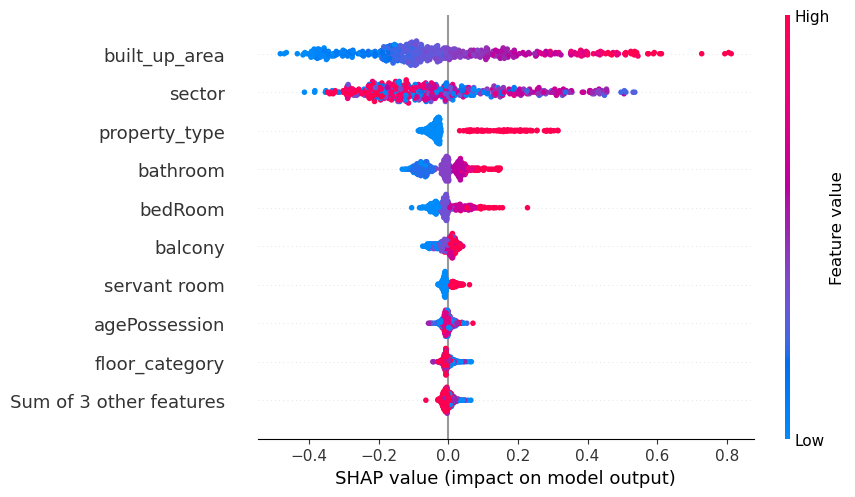

In [38]:
import shap
import pandas as pd

# =========================================================
# CONVERT TEST DATA
# =========================================================

X_test_processed = convert_categories(X_test)

# =========================================================
# CONVERT CATEGORY COLUMNS TO INTEGER CODES
# =========================================================

X_shap = X_test_processed.copy()

for col in cat_cols:

    X_shap[col] = X_shap[col].cat.codes

# =========================================================
# PREDICTION FUNCTION
# =========================================================

def predict_fn(data):

    data = pd.DataFrame(
        data,
        columns=X_shap.columns
    )

    # convert integer codes back to category
    for col in cat_cols:

        data[col] = data[col].astype(int)

        categories = (
            X_test_processed[col]
            .cat.categories
        )

        data[col] = pd.Categorical.from_codes(

            data[col],

            categories=categories
        )

    return pipeline.predict(data)

# =========================================================
# EXPLAINER
# =========================================================

explainer = shap.Explainer(

    predict_fn,

    X_shap
)

# =========================================================
# SHAP VALUES
# =========================================================

print("Calculating SHAP values...")

shap_values = explainer(

     X_shap.sample(500, random_state=42)
)

# =========================================================
# SUMMARY PLOT
# =========================================================

shap.plots.beeswarm(shap_values)